# Notebook 06 — Análisis de Causalidad de Granger
## ¿Anticipa el flujo noticioso (NLP) los movimientos del EMBI?

**Pregunta:** ¿Los cambios en cobertura mediática sobre Ecuador *preceden* a cambios en el EMBI?

**Por qué importa para la tesis:** Los resultados de ablación (NB05) mostraron que el NLP aporta
~2.3 pb de mejora predictiva y los SHAP values mostraron 0.9% del impacto total. Este análisis
va un paso más allá: si existe causalidad de Granger del NLP hacia el EMBI, significa que la
señal mediática contiene información que aún no está incorporada en el precio del bono soberano,
lo cual es consistente con la hipótesis de ineficiencia informacional en mercados emergentes.

**Diseño:**
1. Verificar estacionariedad (requisito del test de Granger)
2. Test NLP → EMBI con lags 1 a 10 días
3. Test inverso EMBI → NLP (para descartar causalidad inversa)
4. Visualizar con heatmap de p-values


In [1]:
# =============================================================================
# 1. IMPORTACIONES
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
print("Librerias cargadas")


Librerias cargadas


In [2]:
# =============================================================================
# 2. CARGA DE DATOS
# =============================================================================
# Usamos el dataset maestro (antes del feature engineering)
# para trabajar con las series originales, no con sus lags artificiales.

df = pd.read_pickle("dataset_tesis_final.pkl")

NLP_COLS = [
    "nlp_event_count",
    "nlp_total_articles",
    "nlp_events_gov",
    "nlp_events_biz",
    "nlp_avg_tone",
    "nlp_goldstein",
]

data = df[["target_embi"] + NLP_COLS].copy()

print(f"Dataset: {data.shape}")
print(f"Periodo: {data.index.min().date()} a {data.index.max().date()}")


Dataset: (3047, 7)
Periodo: 2013-11-01 a 2025-12-30


## 2. Test de Estacionariedad (ADF)

El test de Granger **requiere series estacionarias**.
- **p < 0.05** -> estacionaria (usar directamente)
- **p >= 0.05** -> no estacionaria (diferenciar: delta = valor_hoy - valor_ayer)


In [3]:
# =============================================================================
# 3. TEST ADF
# =============================================================================
def test_adf(serie, nombre):
    res = adfuller(serie.dropna(), autolag="AIC")
    return {
        "Serie": nombre,
        "ADF Stat": round(res[0], 4),
        "p-value": round(res[1], 4),
        "Estacionaria": "Si" if res[1] < 0.05 else "No -> diferenciar"
    }

df_adf = pd.DataFrame([test_adf(data[c], c) for c in ["target_embi"] + NLP_COLS])
print(df_adf.to_string(index=False))

no_estacionarias = df_adf[df_adf["Estacionaria"].str.startswith("No")]["Serie"].tolist()
print(f"\nRequieren diferenciacion: {no_estacionarias}")


             Serie  ADF Stat  p-value Estacionaria
       target_embi   -4.3360   0.0004           Si
   nlp_event_count   -5.0613   0.0000           Si
nlp_total_articles   -4.5250   0.0002           Si
    nlp_events_gov   -7.0944   0.0000           Si
    nlp_events_biz   -3.0893   0.0274           Si
      nlp_avg_tone   -8.8231   0.0000           Si
     nlp_goldstein   -9.1086   0.0000           Si

Requieren diferenciacion: []


In [4]:
# =============================================================================
# 4. DIFERENCIACION
# =============================================================================
data_diff = data.copy()

for col in no_estacionarias:
    data_diff[col] = data[col].diff()
    print(f"Diferenciada: {col}")

data_diff = data_diff.dropna()
print(f"\nDataset estacionario: {data_diff.shape}")

print("\nVerificacion post-diferenciacion:")
for col in ["target_embi"] + NLP_COLS:
    pval = adfuller(data_diff[col].dropna(), autolag="AIC")[1]
    status = "OK" if pval < 0.05 else "REVISAR"
    print(f"  {col:35s}: p={pval:.4f} -> {status}")



Dataset estacionario: (3047, 7)

Verificacion post-diferenciacion:
  target_embi                        : p=0.0004 -> OK
  nlp_event_count                    : p=0.0000 -> OK
  nlp_total_articles                 : p=0.0002 -> OK
  nlp_events_gov                     : p=0.0000 -> OK
  nlp_events_biz                     : p=0.0274 -> OK
  nlp_avg_tone                       : p=0.0000 -> OK
  nlp_goldstein                      : p=0.0000 -> OK


## 3. Test de Causalidad de Granger

**Interpretacion:** Decimos que X *Granger-causa* Y si los valores pasados de X
ayudan a predecir Y mejor que solo los valores pasados de Y.

- **p < 0.05 en lag k** -> la variable NLP de hace k dias anticipa el EMBI de hoy
- Corremos ambas direcciones: NLP->EMBI y EMBI->NLP
- Lags: 1 a 10 dias habiles (~2 semanas calendario)


In [5]:
# =============================================================================
# 5. TEST DE GRANGER
# =============================================================================
MAX_LAG = 10

def granger_pvalues(y_series, x_series, max_lag=MAX_LAG):
    df_test = pd.concat([y_series, x_series], axis=1).dropna()
    try:
        res = grangercausalitytests(df_test, maxlag=max_lag, verbose=False)
        return {lag: res[lag][0]["ssr_ftest"][1] for lag in range(1, max_lag+1)}
    except Exception:
        return {lag: np.nan for lag in range(1, max_lag+1)}

# NLP -> EMBI
print("Corriendo Granger: NLP -> EMBI...")
resultados_nlp_embi = {}
for col in NLP_COLS:
    resultados_nlp_embi[col] = granger_pvalues(
        data_diff["target_embi"], data_diff[col])
    sig = [l for l, p in resultados_nlp_embi[col].items() if p < 0.05]
    print(f"  {col:35s}: lags sig. {sig if sig else []}") 

# EMBI -> NLP (inverso)
print("\nCorriendo Granger inverso: EMBI -> NLP...")
resultados_embi_nlp = {}
for col in NLP_COLS:
    resultados_embi_nlp[col] = granger_pvalues(
        data_diff[col], data_diff["target_embi"])
    sig = [l for l, p in resultados_embi_nlp[col].items() if p < 0.05]
    print(f"  EMBI -> {col:30s}: lags sig. {sig if sig else []}")


Corriendo Granger: NLP -> EMBI...
  nlp_event_count                    : lags sig. []
  nlp_total_articles                 : lags sig. []
  nlp_events_gov                     : lags sig. []
  nlp_events_biz                     : lags sig. []
  nlp_avg_tone                       : lags sig. []
  nlp_goldstein                      : lags sig. []

Corriendo Granger inverso: EMBI -> NLP...
  EMBI -> nlp_event_count               : lags sig. []
  EMBI -> nlp_total_articles            : lags sig. []
  EMBI -> nlp_events_gov                : lags sig. []
  EMBI -> nlp_events_biz                : lags sig. []
  EMBI -> nlp_avg_tone                  : lags sig. [1, 2, 3, 4]
  EMBI -> nlp_goldstein                 : lags sig. [1]


In [6]:
# =============================================================================
# 6. TABLA RESUMEN
# =============================================================================
rows = []
for col in NLP_COLS:
    for lag in range(1, MAX_LAG + 1):
        p_fwd = resultados_nlp_embi[col][lag]
        p_inv = resultados_embi_nlp[col][lag]
        rows.append({
            "Variable NLP":  col,
            "Lag (dias)":    lag,
            "p NLP->EMBI":   round(p_fwd, 4),
            "Sig fwd":       "SI" if p_fwd < 0.05 else "",
            "p EMBI->NLP":   round(p_inv, 4),
            "Sig inv":       "SI" if p_inv < 0.05 else "",
        })

df_granger = pd.DataFrame(rows)

sig_fwd = df_granger[df_granger["Sig fwd"] == "SI"]
sig_inv = df_granger[df_granger["Sig inv"] == "SI"]

print("SIGNIFICATIVOS NLP -> EMBI (p < 0.05):")
print("=" * 55)
if len(sig_fwd) > 0:
    print(sig_fwd[["Variable NLP", "Lag (dias)", "p NLP->EMBI"]].to_string(index=False))
else:
    print("Ninguno")

print("\nSIGNIFICATIVOS EMBI -> NLP (causalidad inversa):")
print("=" * 55)
if len(sig_inv) > 0:
    print(sig_inv[["Variable NLP", "Lag (dias)", "p EMBI->NLP"]].to_string(index=False))
else:
    print("Ninguno")


SIGNIFICATIVOS NLP -> EMBI (p < 0.05):
Ninguno

SIGNIFICATIVOS EMBI -> NLP (causalidad inversa):
 Variable NLP  Lag (dias)  p EMBI->NLP
 nlp_avg_tone           1       0.0000
 nlp_avg_tone           2       0.0004
 nlp_avg_tone           3       0.0041
 nlp_avg_tone           4       0.0205
nlp_goldstein           1       0.0448


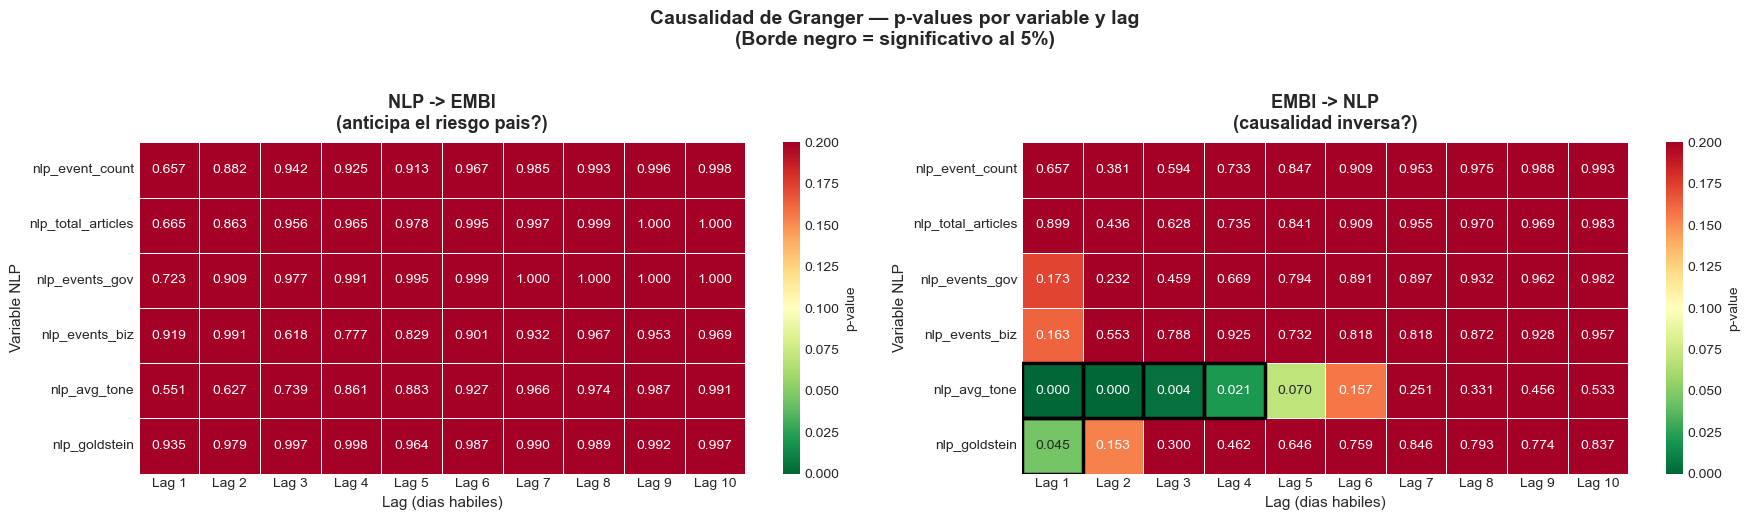

Guardado: granger_heatmap.png


In [7]:
# =============================================================================
# 7. HEATMAP DE P-VALUES
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, resultados, titulo in [
    (axes[0], resultados_nlp_embi, "NLP -> EMBI\n(anticipa el riesgo pais?)"),
    (axes[1], resultados_embi_nlp, "EMBI -> NLP\n(causalidad inversa?)"),
]:
    matrix = pd.DataFrame(resultados).T
    matrix.columns = [f"Lag {l}" for l in range(1, MAX_LAG+1)]

    sns.heatmap(
        matrix, ax=ax, cmap="RdYlGn_r",
        vmin=0, vmax=0.2,
        annot=True, fmt=".3f",
        linewidths=0.5,
        cbar_kws={"label": "p-value"},
    )
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if matrix.iloc[i, j] < 0.05:
                ax.add_patch(plt.Rectangle(
                    (j, i), 1, 1, fill=False, edgecolor="black", lw=2.5))
    ax.set_title(titulo, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Lag (dias habiles)", fontsize=11)
    ax.set_ylabel("Variable NLP", fontsize=11)
    ax.tick_params(axis="y", rotation=0)

plt.suptitle(
    "Causalidad de Granger — p-values por variable y lag\n"
    "(Borde negro = significativo al 5%)",
    fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("granger_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: granger_heatmap.png")


## 4. Interpretacion para la Tesis

### Si encuentras causalidad NLP -> EMBI:
"Las series de cobertura mediatica Granger-causan el EMBI ecuatoriano con un horizonte
de X dias habiles, lo que sugiere que la atencion informacional internacional anticipa
la percepcion de riesgo soberano antes de incorporarse completamente en el precio del bono.
Esto es consistente con la menor liquidez del mercado de deuda ecuatoriana respecto a
mercados desarrollados."

### Si NO encuentras causalidad:
"El test de Granger no encuentra evidencia de anticipacion con rezago. La relacion entre
el NLP y el EMBI es contemporanea: la cobertura mediatica y el riesgo pais se mueven
juntos en el mismo dia, lo que puede reflejar que ambas variables responden simultaneamente
a los mismos eventos macroeconomicos y politicos."

**En ambos casos el resultado es valido y publicable.**


In [8]:
# =============================================================================
# 8. CONCLUSIONES AUTOMATICAS
# =============================================================================
print("=" * 65)
print("CONCLUSIONES DEL ANALISIS DE GRANGER")
print("=" * 65)

if len(sig_fwd) > 0:
    mejor_lag = sig_fwd.groupby("Variable NLP")["Lag (dias)"].min()
    print(f"\n CAUSALIDAD NLP -> EMBI DETECTADA")
    print(f"  Combinaciones significativas: {len(sig_fwd)}")
    print(f"  Horizonte minimo por variable:")
    for var, lag in mejor_lag.items():
        print(f"    {var}: {lag} dia(s)")
    print(f"\n  La senial mediatica anticipa el EMBI con")
    print(f"  {mejor_lag.min()}-{mejor_lag.max()} dias habiles de adelanto.")
else:
    print("\n  Sin causalidad NLP -> EMBI significativa al 5%.")
    print("  La relacion es contemporanea, no predictiva con rezago.")

if len(sig_inv) > 0:
    print(f"\n  ATENCION: Causalidad inversa (EMBI -> NLP) detectada.")
    print(f"  Hay retroalimentacion bidireccional.")
    print(f"  El EMBI alto tambien atrae mayor cobertura mediatica.")
else:
    print(f"\n  Sin causalidad inversa (EMBI -> NLP).")
    print(f"  Si existe relacion, es unidireccional NLP -> EMBI.")


CONCLUSIONES DEL ANALISIS DE GRANGER

  Sin causalidad NLP -> EMBI significativa al 5%.
  La relacion es contemporanea, no predictiva con rezago.

  ATENCION: Causalidad inversa (EMBI -> NLP) detectada.
  Hay retroalimentacion bidireccional.
  El EMBI alto tambien atrae mayor cobertura mediatica.
